# Анализ пространственно-временной динамики ареала лебедей в Северной Америке

---

## Тема проекта

**Анализ пространственно-временной динамики ареала лебедей в Северной Америке.**

---

## Цель проекта

Определить, наблюдается ли статистически значимое смещение ареала лебедей в Северной Америке, и выявить, различается ли это смещение в разных географических зонах. Оценить влияние внешних факторов (температура, плотность населения) на пространственное распределение птиц.

---

## Задачи проекта

1. Загрузить и очистить данные о наблюдениях за лебедями.
2. Добавить внешние данные (плотность населения и температура по штатам и провинциям).
3. Провести кластерный анализ для выделения географических зон.
4. Учесть сезонность и другие искажающие факторы.
5. Провести статистический анализ: оценить тренды, сравнить виды и сезоны.
6. Построить визуализации (не менее 4 графиков).
7. Сформулировать выводы.

---

# Описание датасетов

---

## 1. `short.csv` — наблюдения за лебедями

**Источник:** GBIF (Global Biodiversity Information Facility)

**Объём:** ~3.5 млн записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `gbifID` | int | Уникальный идентификатор наблюдения |
| `basisOfRecord` | str | Тип записи |
| `recordedBy` | str | Наблюдатель |
| `eventDate` | str | Дата наблюдения |
| `year` | int | Год |
| `month` | int | Месяц |
| `day` | int | День |
| `countryCode` | str | Код страны |
| `stateProvince` | str | Штат / провинция |
| `locality` | str | Локация |
| `decimalLatitude` | float | Широта |
| `decimalLongitude` | float | Долгота |
| `coordinateUncertaintyInMeters` | float | — |
| `coordinatePrecision` | float | — |
| `infraspecificEpithet` | float | — |
| `taxonRank` | str | Ранг таксона |
| `datasetKey` | str | Идентификатор источника |
| `elevation` | float | — |
| `elevationAccuracy` | float | — |
| `depth` | float | — |
| `depthAccuracy` | float | — |
| `species` | str | Вид |

**Виды в датасете:**
- `Cygnus olor` — лебедь-шипун
- `Cygnus buccinator` — лебедь-трубач
- `Cygnus columbianus` — американский тундровый лебедь
- `Cygnus atratus` — чёрный лебедь
- `Cygnus cygnus` — лебедь-кликун
- `Cygnus melancoryphus` — черношейный лебедь

---

## 2. `US_CA.csv` — плотность населения

**Объём:** 69 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название штата / провинции |
| `land_area` | float | Площадь, км² |
| `density_per` | float | Плотность населения, чел/км² |

---

## 3. `us_state_temperatures.csv` — температуры США

**Объём:** ~26 868 записей

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state` | str | Название штата |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_f` | float | Температура, °F |
| `avg_temp_c` | float | Температура, °C |

---

## 4. `canada_temperatures.csv` — температуры Канады

**Объём:** 6 864 записи

| Столбец | Тип | Описание |
|---------|-----|----------|
| `state_province` | str | Название провинции |
| `year` | int | Год |
| `month` | int | Месяц |
| `avg_temp_c` | float | Температура, °C |

---

# Задания по предобработке

Выполните следующие шаги в отдельных ячейках ноутбука.

---

### Блок 1. Загрузка и первичный осмотр

1. Загрузите `short.csv`.
2. Выведите `info()`, `shape` и список столбцов.
3. Проверьте количество пропусков по каждому столбцу.

### Блок 2. Очистка структуры данных

4. Удалите столбцы, полностью состоящие из пропусков.
5. Удалите столбец `locality`.
6. Приведите названия столбцов к формату `snake_case` (все буквы строчные, слова разделены `_`).
7. Преобразуйте столбец `event_date` в формат `datetime`.

### Блок 3. Фильтрация данных

8. Оставьте только три вида: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`.
9. Оставьте только наблюдения из США и Канады (`US`, `CA`).
10. Проверьте и при необходимости ограничьте координаты: широта 25–75°, долгота −170…−35°.
11. Удалите столбцы с единственным уникальным значением.
12. Оставьте только годы **до 2023 включительно**.

### Блок 4. Обогащение данными

13. Загрузите `US_CA.csv`. Проверьте и приведите названия штатов/провинций к единому виду с основным датасетом.
14. Объедините основной датасет с данными о плотности населения.
15. Загрузите оба датасета с температурой.
16. Приведите температуры США и Канады к единому формату (названия столбцов, единицы измерения).
17. Объедините их в один датасет температур.
18. Проверьте уникальность пар `(state_province, year, month)`.

### Блок 5. Сезонная фильтрация

19. Оставьте только месяцы:
    - **Зимовка:** декабрь, январь, февраль
    - **Гнездование:** июнь, июль, август
20. Создайте столбец `period_type`: `1` для зимовки, `2` для гнездования.

### Блок 6. Временная разбивка

21. Разделите данные на 5 временных периодов:
    - `1_1980-1988`
    - `2_1989-1997`
    - `3_1998-2006`
    - `4_2007-2015`
    - `5_2016-2023`
22. Создайте столбец `time_period`.

### Блок 7. Работа с координатами и дубликатами

23. Округлите `decimal_latitude` и `decimal_longitude` до целых чисел.
24. Удалите дубликаты по набору `(year, period_type, decimal_longitude, decimal_latitude, species)`.

### Блок 8. Объединение с температурой

25. Объедините датасет с `temperatures_US_CA` по ключу `(state_province, year, month)`.
26. Проверьте пропуски в температуре. Заполните их средним значением по `(state_province, month)`.

### Блок 9. Сохранение и финальная проверка

27. Сохраните подготовленный датасет в `data_seasonal_enriched.csv`.
28. Выведите:
    - общее количество записей,
    - распределение по периодам,
    - распределение по видам,
    - среднюю температуру по сезонам,
    - среднюю широту по сезонам.

---

# Рекомендуемые статистические методы

Ниже — перечень методов, которые можно применять. Выбирайте в зависимости от вопроса.

---

### 1. Кластерный анализ (обязательно)

**Зачем:** разделить наблюдения на географические зоны.

**Пример:**
```python
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler

coords = df[['decimal_latitude', 'decimal_longitude']].values
coords_scaled = StandardScaler().fit_transform(coords)

linkage_matrix = linkage(coords_scaled, method='ward')
df['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')
```

---

### 2. Описательная статистика

**Зачем:** понять распределение данных по группам.

**Пример:**
```python
df.groupby('species')['decimal_latitude'].describe()
df.groupby('period_type')['avg_temp_c'].mean()
```

---

### 3. Линейная регрессия

**Зачем:** оценить, меняется ли широта со временем (тренд).

**Пример:**
```python
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(df['year'], df['decimal_latitude'])
print(f"Наклон: {slope}, p-value: {p_value}, R²: {r_value**2}")
```

**Как читать:** если `p_value < 0.05` — тренд значим. Знак `slope` показывает направление.

---

### 4. Корреляционный анализ

**Зачем:** оценить связь между переменными.

**Пример:**
```python
from scipy.stats import pearsonr, spearmanr

r, p = pearsonr(df['avg_temp_c'], df['decimal_latitude'])
print(f"Пирсон: r = {r:.3f}, p = {p:.4f}")

rho, p = spearmanr(df['avg_temp_c'], df['decimal_latitude'])
print(f"Спирмен: ρ = {rho:.3f}, p = {p:.4f}")
```

**Как читать:** `p < 0.05` — связь значима. `r` показывает силу и направление.

---

### 5. Сравнение групп: Kruskal-Wallis

**Зачем:** проверить, различаются ли три и более групп (например, три вида).

**Пример:**
```python
from scipy.stats import kruskal

groups = [df[df['species'] == sp]['decimal_latitude'] for sp in df['species'].unique()]
stat, p = kruskal(*groups)
print(f"H = {stat:.2f}, p = {p:.4f}")
```

**Как читать:** если `p < 0.05` — группы различаются.

---

### 6. Попарные сравнения: Mann-Whitney U

**Зачем:** сравнить две конкретные группы.

**Пример:**
```python
from scipy.stats import mannwhitneyu

g1 = df[df['species'] == 'Cygnus olor']['decimal_latitude']
g2 = df[df['species'] == 'Cygnus buccinator']['decimal_latitude']
stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
print(f"p = {p:.4f}")
```

---

### 7. Множественная регрессия

**Зачем:** оценить вклад нескольких факторов одновременно.

**Пример:**
```python
import statsmodels.api as sm

X = df[['year', 'avg_temp_c', 'density_per']]
X = sm.add_constant(X)
y = df['decimal_latitude']

model = sm.OLS(y, X).fit()
print(model.summary())
```

**Как читать:** смотрите на `p-value` каждого коэффициента и на `R²` модели.

---

### 8. Бутстрап (опционально)

**Зачем:** получить доверительные интервалы без предположения о нормальности.

**Пример:**
```python
import numpy as np

slopes = []
for _ in range(500):
    sample = df.sample(len(df), replace=True)
    slope = np.polyfit(sample['year'], sample['decimal_latitude'], 1)[0]
    slopes.append(slope)

ci_low, ci_high = np.percentile(slopes, [2.5, 97.5])
print(f"95% ДИ: [{ci_low:.4f}, {ci_high:.4f}]")
```

---

### 9. Шпаргалка: какой тест для какого вопроса

| Вопрос | Метод |
|--------|-------|
| Как разбить наблюдения на зоны? | Кластерный анализ |
| Есть ли тренд во времени? | Линейная регрессия |
| Связаны ли две переменные? | Корреляция (Пирсон/Спирмен) |
| Различаются ли группы? | Kruskal-Wallis |
| Различаются ли две группы? | Mann-Whitney U |
| Что важнее: год, температура, плотность? | Множественная регрессия |
| Как устойчив результат? | Бутстрап |

---

# Обязательные визуализации

Постройте минимум **4 графика** из списка:

1. **Карта кластеров** — точки на плоскости «долгота × широта», цвет — кластер.
2. **Дендрограмма** кластеризации.
3. **График тренда** — средняя широта по годам с линией регрессии (хотя бы для одного кластера).
4. **Boxplot** — сравнение широты или температуры по видам.
5. **Тепловая карта корреляций**.
6. **Диаграмма рассеяния** — широта vs температура.

---

# Критерии оценки

| № | Критерий | Баллы |
|---|----------|-------|
| 1 | Данные загружены и очищены | 1 |
| 2 | Обрезка по годам и фильтрация выполнены | 1 |
| 3 | Обогащение данными (плотность, температура) выполнено | 1 |
| 4 | Сезонная фильтрация и разбиение на периоды выполнены | 1 |
| 5 | Кластерный анализ выполнен, выделено 5 кластеров | 1 |
| 6 | Построено минимум 4 визуализации | 1 |
| 7 | Применён хотя бы один статистический тест | 1 |
| 8 | Выводы сформулированы | 1 |
| 9 | Датасет сохранён в CSV | 1 |
| **Итого** | | **9** |

---

# Формат итогового отчёта

Ноутбук должен содержать:

1. Введение (цель, задачи, данные).
2. Предобработку данных (код + краткие пояснения).
3. Обогащение данными.
4. Кластерный анализ.
5. Статистический анализ.
6. Визуализации.
7. Выводы (что удалось выяснить, ограничения).

---

# ЧАСТЬ 2. КОД (шаблон для заполнения)

---

## 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols
from itertools import combinations

sns.set_style('whitegrid')

## 2. Загрузка данных

In [2]:
data = pd.read_csv(r'C:\Users\Дмитрий\Desktop\Проект Анализ ареала лебедей в Северной Америке\datasets_ipynb\short.csv')
data.info()
print(data.shape)
print(data.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489498 entries, 0 to 3489497
Data columns (total 22 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   gbifID                         int64  
 1   basisOfRecord                  object 
 2   recordedBy                     object 
 3   eventDate                      object 
 4   year                           int64  
 5   month                          int64  
 6   day                            int64  
 7   countryCode                    object 
 8   stateProvince                  object 
 9   locality                       object 
 10  decimalLatitude                float64
 11  decimalLongitude               float64
 12  coordinateUncertaintyInMeters  float64
 13  coordinatePrecision            float64
 14  infraspecificEpithet           float64
 15  taxonRank                      object 
 16  datasetKey                     object 
 17  elevation                      float64
 18  el

## 3. Удаление пустых столбцов

> TODO: удалите столбцы, полностью состоящие из пропусков, и столбец `locality`.

In [3]:
# Удаляем столбцы, полностью состоящие из пропусков
empty_cols = data.columns[data.isna().all()].tolist()
print('Полностью пустые столбцы (удаляем):', empty_cols)
print('Их количество:', len(empty_cols))
data = data.drop(columns=empty_cols)

# Удаляем locality
print('\nУдаляем столбец: locality')
print('Пропусков в locality:', data['locality'].isna().sum(), 'из', len(data))
data = data.drop(columns=['locality'])

# Проверяем
print('\nОсталось столбцов:', data.shape[1])
print('Список столбцов:', list(data.columns))


Полностью пустые столбцы (удаляем): ['coordinateUncertaintyInMeters', 'coordinatePrecision', 'infraspecificEpithet', 'elevation', 'elevationAccuracy', 'depth', 'depthAccuracy']
Их количество: 7

Удаляем столбец: locality
Пропусков в locality: 4 из 3489498

Осталось столбцов: 14
Список столбцов: ['gbifID', 'basisOfRecord', 'recordedBy', 'eventDate', 'year', 'month', 'day', 'countryCode', 'stateProvince', 'decimalLatitude', 'decimalLongitude', 'taxonRank', 'datasetKey', 'species']


## 4. Переименование столбцов в snake_case

> TODO: примените функцию `camel_to_snake` ко всем столбцам.

In [4]:
def camel_to_snake(name):
    '''Преобразует CamelCase в snake_case.'''
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

# Ваш код здесь
data.columns = [camel_to_snake(c) for c in data.columns]

print('Столбцы после snake_case:')
for c in data.columns:
    print(' ', c)


Столбцы после snake_case:
  gbif_id
  basis_of_record
  recorded_by
  event_date
  year
  month
  day
  country_code
  state_province
  decimal_latitude
  decimal_longitude
  taxon_rank
  dataset_key
  species


## 5. Преобразование типа event_date

> TODO: приведите `event_date` к `datetime`.

In [5]:
# Приводим event_date к datetime
data['event_date'] = pd.to_datetime(data['event_date'], errors='coerce')

print('Тип event_date:', data['event_date'].dtype)
print('Пропуски в event_date после конвертации:', data['event_date'].isna().sum())
print('\nПримеры:')
print(data['event_date'].head())
print('\nДиапазон дат:', data['event_date'].min(), '—', data['event_date'].max())

Тип event_date: datetime64[ns]
Пропуски в event_date после конвертации: 0

Примеры:
0   2008-01-19
1   2021-01-23
2   2024-03-21
3   2020-05-28
4   2021-09-09
Name: event_date, dtype: datetime64[ns]

Диапазон дат: 1980-01-01 00:00:00 — 2024-12-31 00:00:00


## 6. Фильтрация данных

> TODO:
> - оставить только три вида: `Cygnus olor`, `Cygnus buccinator`, `Cygnus columbianus`;
> - оставить только US и CA;
> - ограничить координаты (широта 25–75°, долгота −170…−35°);
> - удалить столбцы с единственным уникальным значением.

In [6]:
# Оставляем только три вида Cygnus olor, Cygnus buccinator, Cygnus columbianus
species_keep = ['Cygnus olor', 'Cygnus buccinator', 'Cygnus columbianus']
print('Виды до фильтрации:')
print(data['species'].value_counts())

data = data[data['species'].isin(species_keep)]

print('\nВиды после фильтрации:')
print(data['species'].value_counts())

Виды до фильтрации:
Cygnus olor             1810815
Cygnus buccinator        998765
Cygnus columbianus       669942
Cygnus atratus             6020
Cygnus cygnus              3218
Cygnus melancoryphus        738
Name: species, dtype: int64

Виды после фильтрации:
Cygnus olor           1810815
Cygnus buccinator      998765
Cygnus columbianus     669942
Name: species, dtype: int64


In [7]:
# Оставляем только US и CA
print('\nСтраны ДО:', data['country_code'].unique())
data = data[data['country_code'].isin(['US', 'CA'])]
print('Страны ПОСЛЕ:', data['country_code'].unique())


Страны ДО: ['US' 'CA' 'MX' 'BM' 'DO' 'PR' 'VI']
Страны ПОСЛЕ: ['US' 'CA']


In [8]:
# Ограничиваем координаты
before = len(data)
data = data[
    data['decimal_latitude'].between(25, 75) &
    data['decimal_longitude'].between(-170, -35)
]
after = len(data)
print(f'Фильтр по координатам:')
print(f'Было {before}')
print(f'Стало {after} (убрано {before - after})')

Фильтр по координатам:
Было 3479482
Стало 3477414 (убрано 2068)


In [9]:
# Удаляем столбцы с единственным уникальным значением
const_cols = [c for c in data.columns if data[c].nunique(dropna=False) == 1]
print('\nКонстантные столбцы (удаляем):', const_cols)
data = data.drop(columns=const_cols)

print('Итог:', data.shape)
print('Столбцы:', list(data.columns))


Константные столбцы (удаляем): ['basis_of_record', 'taxon_rank', 'dataset_key']
Итог: (3477414, 11)
Столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species']


## 7. Обрезка по годам

> TODO: оставьте только `year <= 2023`.

In [10]:
# Оставляем year <= 2023
before = len(data)
data = data[data['year'] <= 2023]
after = len(data)
print(f'Фильтр по годам: было {before} → стало {after} (убрано {before - after})')
print('Новый диапазон лет:', data['year'].min(), '—', data['year'].max())
print('\nИтог:', data.shape)

Фильтр по годам: было 3477414 → стало 3033096 (убрано 444318)
Новый диапазон лет: 1980 — 2023

Итог: (3033096, 11)


## 8. Загрузка внешних данных

> TODO:
> - загрузите `US_CA.csv`, `us_state_temperatures.csv`, `canada_temperatures.csv`;
> - приведите названия штатов и провинций к единому виду;
> - приведите датасеты температур к единому формату.

In [11]:
df_US_CA = pd.read_csv(r'C:\Users\Дмитрий\Desktop\Проект Анализ ареала лебедей в Северной Америке\datasets_ipynb\US_CA.csv')
us_temperatures = pd.read_csv(r'C:\Users\Дмитрий\Desktop\Проект Анализ ареала лебедей в Северной Америке\datasets_ipynb\us_state_temperatures.csv')
ca_temperatures = pd.read_csv(r'C:\Users\Дмитрий\Desktop\Проект Анализ ареала лебедей в Северной Америке\datasets_ipynb\canada_temperatures.csv')

# Ваш код здесь

print('=== df_US_CA ===')
df_US_CA.info()
print('Shape:', df_US_CA.shape)
print('Пропуски:')
print(df_US_CA.isna().sum())

print('\n=== us_temperatures ===')
us_temperatures.info()
print('Shape:', us_temperatures.shape)
print('Пропуски:')
print(us_temperatures.isna().sum())

print('\n=== ca_temperatures ===')
ca_temperatures.info()
print('Shape:', ca_temperatures.shape)
print('Пропуски:')
print(ca_temperatures.isna().sum())

=== df_US_CA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   state_province  69 non-null     object 
 1   land_area       69 non-null     float64
 2   density_per     69 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.7+ KB
Shape: (69, 3)
Пропуски:
state_province    0
land_area         0
density_per       0
dtype: int64

=== us_temperatures ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26868 entries, 0 to 26867
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   state       26868 non-null  object 
 1   year        26868 non-null  int64  
 2   month       26868 non-null  int64  
 3   avg_temp_f  26868 non-null  float64
 4   avg_temp_c  26868 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.0+ MB
Shape: (26868, 5)
Пропус

In [12]:
# Переименовываем: state в state_province в us_temperatures
print('Столбцы ДО:', list(us_temperatures.columns))
us_temperatures = us_temperatures.rename(columns={'state': 'state_province'})
print('Столбцы ПОСЛЕ:', list(us_temperatures.columns))

Столбцы ДО: ['state', 'year', 'month', 'avg_temp_f', 'avg_temp_c']
Столбцы ПОСЛЕ: ['state_province', 'year', 'month', 'avg_temp_f', 'avg_temp_c']


In [13]:
# Проверяем название штатов/провинций + количество уникальных

print('=== df_US_CA ===')
print('Уникальных:', df_US_CA['state_province'].nunique())
print(sorted(df_US_CA['state_province'].unique()))

print('\n=== us_temperatures ===')
print('Уникальных:', us_temperatures['state_province'].nunique())
print(sorted(us_temperatures['state_province'].unique()))

print('\n=== ca_temperatures ===')
print('Уникальных:', ca_temperatures['state_province'].nunique())
print(sorted(ca_temperatures['state_province'].unique()))

=== df_US_CA ===
Уникальных: 69
['AB', 'Alabama', 'Alaska', 'American Samoa[4]', 'Arizona', 'Arkansas', 'British Columbia', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Guam[4]', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Manitoba', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Brunswick', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'Newfoundland and Labrador', 'North Carolina', 'North Dakota', 'Northern Mariana Islands[4]', 'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ohio', 'Oklahoma', 'Ontario', 'Oregon', 'Pennsylvania', 'Prince Edward Island', 'Puerto Rico', 'Quebec', 'Rhode Island', 'Saskatchewan', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'U.S. Virgin Islands[4]', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'Yukon']

=== us_temp

In [14]:
# Унифицируем названия

# df_US_CA: сокращения + мусорные территории
df_US_CA['state_province'] = df_US_CA['state_province'].replace({
    'AB': 'Alberta',
    'Yukon': 'Yukon Territory'
})
junk = ['American Samoa[4]', 'Guam[4]', 'Northern Mariana Islands[4]',
        'Puerto Rico', 'U.S. Virgin Islands[4]', 'Hawaii']
df_US_CA = df_US_CA[~df_US_CA['state_province'].isin(junk)]

# us_temperatures: подчёркивания -> пробелы
us_temperatures['state_province'] = us_temperatures['state_province'].str.replace('_', ' ')

# Проверка
print('df_US_CA:        ', df_US_CA['state_province'].nunique())
print('us_temperatures: ', us_temperatures['state_province'].nunique())
print('ca_temperatures: ', ca_temperatures['state_province'].nunique())

df_US_CA:         63
us_temperatures:  50
ca_temperatures:  13


In [15]:
# Соединяем data и  плотность населения
before = len(data)
data = data.merge(
    df_US_CA[['state_province', 'density_per']],
    on='state_province',
    how='left'
)
after = len(data)

print(f'Merge с плотностью: было {before} → стало {after}')
print('Пропуски в density_per:', data['density_per'].isna().sum())
print('Shape:', data.shape)
print('Столбцы:', list(data.columns))

Merge с плотностью: было 3033096 → стало 3033096
Пропуски в density_per: 0
Shape: (3033096, 12)
Столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species', 'density_per']


In [16]:
# Приведение температурных датасетов к единому формату

# US: state -> state_province уже сделано; оставляем только °C
us_temperatures = us_temperatures[['state_province', 'year', 'month', 'avg_temp_c']]
us_temperatures['country_code'] = 'US'

# CA: уже в °C, добавляем флаг страны
ca_temperatures = ca_temperatures[['state_province', 'year', 'month', 'avg_temp_c']]
ca_temperatures['country_code'] = 'CA'

# Объединяем в один
temperatures = pd.concat([us_temperatures, ca_temperatures], ignore_index=True)

print('Shape:', temperatures.shape)
print('Столбцы:', list(temperatures.columns))
print('Страны:', temperatures['country_code'].value_counts().to_dict())
print('\nПроверка уникальности (state_province, year, month):')
print('Дублей:', temperatures.duplicated(subset=['state_province', 'year', 'month']).sum())
print('\nПример:')
print(temperatures.head())

Shape: (33732, 5)
Столбцы: ['state_province', 'year', 'month', 'avg_temp_c', 'country_code']
Страны: {'US': 26868, 'CA': 6864}

Проверка уникальности (state_province, year, month):
Дублей: 0

Пример:
  state_province  year  month  avg_temp_c country_code
0        Alabama  1980      1    8.166667           US
1        Alabama  1980      2    5.944444           US
2        Alabama  1980      3   11.444444           US
3        Alabama  1980      4   15.888889           US
4        Alabama  1980      5   21.222222           US


## 9. Сезонная фильтрация

> TODO:
> - оставьте только декабрь, январь, февраль и июнь, июль, август;
> - создайте столбец `period_type` (1 = зимовка, 2 = гнездование).

In [17]:
# Ваш код здесь
# Оставляем только декабрь, январь, февраль и июнь, июль, август
winter_months = [12, 1, 2]
nesting_months = [6, 7, 8]
months_keep = winter_months + nesting_months

before = len(data)
data = data[data['month'].isin(months_keep)].copy()
after = len(data)

print(f'Фильтр по месяцам: было {before} → стало {after} (убрано {before - after})')
print('Месяцы в данных:', sorted(data['month'].unique()))


Фильтр по месяцам: было 3033096 → стало 1289670 (убрано 1743426)
Месяцы в данных: [1, 2, 6, 7, 8, 12]


In [18]:
# Создаём period_type
data['period_type'] = np.where(data['month'].isin(winter_months), 1, 2)

print('\nРаспределение period_type:')
print(data['period_type'].value_counts().sort_index())
print('(1 = зимовка, 2 = гнездование)')

print('\nПроверка по месяцам:')
print(data.groupby('period_type')['month'].unique())


Распределение period_type:
1    909198
2    380472
Name: period_type, dtype: int64
(1 = зимовка, 2 = гнездование)

Проверка по месяцам:
period_type
1    [1, 12, 2]
2     [8, 7, 6]
Name: month, dtype: object


## 10. Разбивка на временные периоды

> TODO: создайте столбец `time_period` с 5 интервалами:
> `1_1980-1988`, `2_1989-1997`, `3_1998-2006`, `4_2007-2015`, `5_2016-2023`.

In [19]:
# Ваш код здесь
# Создаем столбец time_period с 5 интервалами

bins = [1980, 1988, 1997, 2006, 2015, 2023]
labels = ['1_1980-1988', '2_1989-1997', '3_1998-2006', '4_2007-2015', '5_2016-2023']

data['time_period'] = pd.cut(
    data['year'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print('Распределение по периодам:')
print(data['time_period'].value_counts().sort_index())
print('\nПропуски в time_period:', data['time_period'].isna().sum())
print('\nПроверка диапазонов:')
print(data.groupby('time_period')['year'].agg(['min', 'max', 'count']))

Распределение по периодам:
1_1980-1988      6003
2_1989-1997     13223
3_1998-2006     34526
4_2007-2015    251921
5_2016-2023    983997
Name: time_period, dtype: int64

Пропуски в time_period: 0

Проверка диапазонов:
              min   max   count
time_period                    
1_1980-1988  1980  1988    6003
2_1989-1997  1989  1997   13223
3_1998-2006  1998  2006   34526
4_2007-2015  2007  2015  251921
5_2016-2023  2016  2023  983997


## 11. Округление координат и удаление дубликатов

> TODO: округлите координаты до целых и удалите дубликаты по набору
> `(year, period_type, decimal_longitude, decimal_latitude, species)`.

In [20]:
# Ваш код здесь
# Округляем координаты до целых
data['decimal_latitude'] = data['decimal_latitude'].round().astype(int)
data['decimal_longitude'] = data['decimal_longitude'].round().astype(int)

print(f"decimal_latitude Тип: {data['decimal_latitude'].dtype}")
print(f"decimal_longitude Тип: {data['decimal_longitude'].dtype}")
# Удаляем дубликаты
before = len(data)
data = data.drop_duplicates(
    subset=['year', 'period_type', 'decimal_longitude', 'decimal_latitude', 'species']
)
after = len(data)

print(f'\nДубликаты: было {before} → стало {after} (убрано {before - after})')
print('Shape:', data.shape)

decimal_latitude Тип: int32
decimal_longitude Тип: int32

Дубликаты: было 1289670 → стало 33095 (убрано 1256575)
Shape: (33095, 14)


## 12. Объединение с температурой

> TODO:
> - объедините датасет с `temperatures_US_CA` по ключу `(state_province, year, month)`;
> - заполните пропуски температуры средним значением по `(state_province, month)`.

In [21]:
# Ваш код здесь
# Объединяем с температурами по (state_province, year, month)
before = len(data)
data = data.merge(
    temperatures[['state_province', 'year', 'month', 'avg_temp_c']],
    on=['state_province', 'year', 'month'],
    how='left'
)
after = len(data)

print(f'Объединенеи с температурой: было {before} → стало {after}')
print('Пропуски в avg_temp_c:', data['avg_temp_c'].isna().sum())
print('Shape:', data.shape)
print('Столбцы:', list(data.columns))

Объединенеи с температурой: было 33095 → стало 33095
Пропуски в avg_temp_c: 5
Shape: (33095, 15)
Столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species', 'density_per', 'period_type', 'time_period', 'avg_temp_c']


In [22]:
# Заполняем пропуски средним по (state_province, month)
data['avg_temp_c'] = data.groupby(['state_province', 'month'])['avg_temp_c'].transform(
    lambda x: x.fillna(x.mean())
)

# Если по региону вообще нет температур — берём среднее по стране+месяц
data['avg_temp_c'] = data.groupby(['country_code', 'month'])['avg_temp_c'].transform(
    lambda x: x.fillna(x.mean())
)

print('Пропусков температуры:', data['avg_temp_c'].isna().sum())
print('\nЗаполненные значения (DC):')
print(data[data['state_province'] == 'District of Columbia'][
    ['state_province', 'year', 'month', 'avg_temp_c']
].drop_duplicates())

Пропусков температуры: 0

Заполненные значения (DC):
             state_province  year  month  avg_temp_c
4655   District of Columbia  2015      7   20.617203
4881   District of Columbia  2015     12    0.373886
26099  District of Columbia  2002      8   19.661251
27977  District of Columbia  2004      6   16.448709
30260  District of Columbia  2005      7   20.617203


## 13. Сохранение датасета

> TODO: сохраните подготовленный датасет в `data_seasonal_enriched.csv`.

In [23]:
# Ваш код здесь
# Сохраняем датасет в data_seasonal_enriched.csv
data.to_csv('data_seasonal_enriched.csv', index=False)

print('Сохранено: data_seasonal_enriched.csv')
print('Shape:', data.shape)
print('Столбцы:', list(data.columns))

Сохранено: data_seasonal_enriched.csv
Shape: (33095, 15)
Столбцы: ['gbif_id', 'recorded_by', 'event_date', 'year', 'month', 'day', 'country_code', 'state_province', 'decimal_latitude', 'decimal_longitude', 'species', 'density_per', 'period_type', 'time_period', 'avg_temp_c']


## 14. Финальная проверка

> TODO: выведите:
> - общее количество записей;
> - распределение по периодам;
> - распределение по видам;
> - среднюю температуру по сезонам;
> - среднюю широту по сезонам.

In [24]:
# Ваш код здесь
# Финальная проверка подготовленного датасета

# 1. Общее количество записей
print('=== Общее количество записей ===')
print(f'Всего наблюдений: {len(data):,}')

# 2. Распределение по периодам
print('\n=== Распределение по временным периодам ===')
print(data['time_period'].value_counts().sort_index())

# 3. Распределение по видам
print('\n=== Распределение по видам ===')
print(data['species'].value_counts())

# 4. Средняя температура по сезонам
print('\n=== Средняя температура по сезонам ===')
temp_by_season = data.groupby('period_type')['avg_temp_c'].mean().round(2)
temp_by_season.index = ['1 = зимовка', '2 = гнездование']
print(temp_by_season)

# 5. Средняя широта по сезонам
print('\n=== Средняя широта по сезонам ===')
lat_by_season = data.groupby('period_type')['decimal_latitude'].mean().round(2)
lat_by_season.index = ['1 = зимовка', '2 = гнездование']
print(lat_by_season)

=== Общее количество записей ===
Всего наблюдений: 33,095

=== Распределение по временным периодам ===
1_1980-1988     1685
2_1989-1997     2920
3_1998-2006     5317
4_2007-2015     9732
5_2016-2023    13441
Name: time_period, dtype: int64

=== Распределение по видам ===
Cygnus buccinator     11880
Cygnus columbianus    11069
Cygnus olor           10146
Name: species, dtype: int64

=== Средняя температура по сезонам ===
1 = зимовка        -0.60
2 = гнездование    17.45
Name: avg_temp_c, dtype: float64

=== Средняя широта по сезонам ===
1 = зимовка        41.78
2 = гнездование    49.25
Name: decimal_latitude, dtype: float64


## 15. Кластерный анализ

> TODO: агрегируйте данные по ячейкам (широта + долгота),
> стандартизируйте координаты, примените метод Уорда,
> выделите 5 кластеров.

In [25]:
# Ваш код здесь
# Агрегация по ячейкам (широта + долгота)
cells = data.groupby(['decimal_latitude', 'decimal_longitude']).size().reset_index(name='count')
print('Уникальных ячеек:', len(cells))

# Стандартизация координат
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(cells[['decimal_latitude', 'decimal_longitude']])

# Метод Уорда
linkage_matrix = linkage(coords_scaled, method='ward')

# Выделяем 5 кластеров
cells['cluster'] = fcluster(linkage_matrix, t=5, criterion='maxclust')

print('\nРаспределение по кластерам:')
print(cells['cluster'].value_counts().sort_index())

# Присоединяем кластер обратно к data
data = data.merge(
    cells[['decimal_latitude', 'decimal_longitude', 'cluster']],
    on=['decimal_latitude', 'decimal_longitude'],
    how='left'
)

print('\nПропуски в cluster:', data['cluster'].isna().sum())
print('Shape:', data.shape)

# 6. Средние координаты каждого кластера — понять, где какая зона
print('\nЦентроиды кластеров:')
print(cells.groupby('cluster')[['decimal_latitude', 'decimal_longitude']].mean().round(2))

Уникальных ячеек: 1756

Распределение по кластерам:
1    471
2    368
3    274
4    310
5    333
Name: cluster, dtype: int64

Пропуски в cluster: 0
Shape: (33095, 16)

Центроиды кластеров:
         decimal_latitude  decimal_longitude
cluster                                     
1                   41.21            -106.46
2                   38.15             -82.21
3                   64.28            -152.95
4                   58.58            -123.99
5                   57.88             -94.62


## 16. Описательная статистика по кластерам

> TODO: выведите среднюю широту, температуру и число записей
> по каждому кластеру.

In [26]:
# Ваш код здесь
# Сводка по кластерам: средняя широта, температура, число записей

summary = data.groupby('cluster').agg(
    n_records=('gbif_id', 'count'),
    mean_latitude=('decimal_latitude', 'mean'),
    mean_temp=('avg_temp_c', 'mean')
).round(2)

print(summary)

         n_records  mean_latitude  mean_temp
cluster                                     
1            13580          42.83       5.39
2            12743          39.67       7.07
3             2606          63.73       9.50
4             2853          54.85       6.06
5             1313          55.52      12.78


## 17. Линейная регрессия по кластерам

> TODO: для каждого кластера постройте тренд широты по годам
> и выведите `slope`, `R²`, `p-value`.

In [27]:
# Ваш код здесь
# Тренд широты по годам для каждого кластера

print(f'{"Кластер":<8} {"n":<7} {"slope":<10} {"R²":<8} {"p-value":<10} {"Значимость"}')
print('-' * 60)

for cl in sorted(data['cluster'].unique()):
    sub = data[data['cluster'] == cl]

    # Средняя широта по годам
    yearly = sub.groupby('year')['decimal_latitude'].mean().reset_index()

    # Нужно минимум 3 точки для регрессии
    if len(yearly) < 3:
        print(f'{cl:<8} мало данных')
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        yearly['year'], yearly['decimal_latitude']
    )

    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'

    print(f'{cl:<8} {len(sub):<7} {slope:>+8.4f}   {r_value**2:<8.3f} {p_value:<10.4f} {sig}')

Кластер  n       slope      R²       p-value    Значимость
------------------------------------------------------------
1        13580    -0.0120   0.160    0.0071     **
2        12743    -0.0247   0.549    0.0000     ***
3        2606     -0.0142   0.021    0.3496     ns
4        2853     +0.0159   0.010    0.5135     ns
5        1313     -0.0939   0.127    0.0175     *


## 18. Корреляционный анализ

> TODO: посчитайте корреляцию:
> - широта vs температура (в целом и по сезонам);
> - широта vs плотность населения.

In [28]:
# Ваш код здесь
# Широта vs температура: в целом
r, p = pearsonr(data['decimal_latitude'], data['avg_temp_c'])
rho, p_s = spearmanr(data['decimal_latitude'], data['avg_temp_c'])
print('=== Широта vs Температура (в целом) ===')
print(f'Пирсон:  r = {r:+.3f},  p = {p:.4f}')
print(f'Спирмен: ρ = {rho:+.3f}, p = {p_s:.4f}')

# Широта vs температура: по сезонам 
print('\n=== Широта vs Температура (по сезонам) ===')
for season, name in [(1, 'зимовка'), (2, 'гнездование')]:
    sub = data[data['period_type'] == season]
    r, p = pearsonr(sub['decimal_latitude'], sub['avg_temp_c'])
    rho, p_s = spearmanr(sub['decimal_latitude'], sub['avg_temp_c'])
    print(f'\n{name} (n={len(sub)}):')
    print(f'  Пирсон:  r = {r:+.3f},  p = {p:.4f}')
    print(f'  Спирмен: ρ = {rho:+.3f}, p = {p_s:.4f}')


=== Широта vs Температура (в целом) ===
Пирсон:  r = +0.036,  p = 0.0000
Спирмен: ρ = -0.016, p = 0.0032

=== Широта vs Температура (по сезонам) ===

зимовка (n=19687):
  Пирсон:  r = -0.637,  p = 0.0000
  Спирмен: ρ = -0.598, p = 0.0000

гнездование (n=13408):
  Пирсон:  r = -0.875,  p = 0.0000
  Спирмен: ρ = -0.869, p = 0.0000


In [29]:
# Широта vs плотность населения
r, p = pearsonr(data['decimal_latitude'], data['density_per'])
rho, p_s = spearmanr(data['decimal_latitude'], data['density_per'])
print('\n=== Широта vs Плотность населения ===')
print(f'Пирсон:  r = {r:+.3f},  p = {p:.4f}')
print(f'Спирмен: ρ = {rho:+.3f}, p = {p_s:.4f}')


=== Широта vs Плотность населения ===
Пирсон:  r = -0.329,  p = 0.0000
Спирмен: ρ = -0.693, p = 0.0000


## 19. Сравнение групп (Kruskal-Wallis, Mann-Whitney)

> TODO:
> - сравните виды по широте и температуре;
> - сравните сезоны по широте;
> - проведите попарные сравнения видов.

In [30]:
# Ваш код здесь
# Сравнение видов по широте и температуре (Kruskal-Wallis) ---
print('=== Kruskal-Wallis: различаются ли виды? ===')

for var in ['decimal_latitude', 'avg_temp_c']:
    groups = [data[data['species'] == sp][var].dropna() for sp in data['species'].unique()]
    stat, p = kruskal(*groups)
    print(f'{var:<20} H = {stat:>8.2f},  p = {p:.4e}')

=== Kruskal-Wallis: различаются ли виды? ===
decimal_latitude     H =  4528.09,  p = 0.0000e+00
avg_temp_c           H =  1502.61,  p = 0.0000e+00


In [31]:
# Сравнение сезонов по широте (Mann-Whitney) ---
print('\n=== Mann-Whitney: различаются ли сезоны по широте? ===')
winter = data[data['period_type'] == 1]['decimal_latitude']
summer = data[data['period_type'] == 2]['decimal_latitude']

stat, p = mannwhitneyu(winter, summer, alternative='two-sided')
print(f'зимовка vs гнездование: U = {stat:.0f}, p = {p:.4e}')
print(f'  медиана зимовка:    {winter.median():.2f}')
print(f'  медиана гнездование:{summer.median():.2f}')


=== Mann-Whitney: различаются ли сезоны по широте? ===
зимовка vs гнездование: U = 72489238, p = 0.0000e+00
  медиана зимовка:    42.00
  медиана гнездование:45.00


In [32]:
# Попарные сравнения видов (Mann-Whitney) ---
print('\n=== Попарные сравнения видов по широте ===')
species = sorted(data['species'].unique())

for sp1, sp2 in combinations(species, 2):
    g1 = data[data['species'] == sp1]['decimal_latitude']
    g2 = data[data['species'] == sp2]['decimal_latitude']
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{sp1:<22} vs {sp2:<22} p = {p:.4e}  {sig}')
    print(f'   медиана: {g1.median():>6.2f}  vs  {g2.median():>6.2f}')


=== Попарные сравнения видов по широте ===
Cygnus buccinator      vs Cygnus columbianus     p = 1.2670e-119  ***
   медиана:  45.00  vs   43.00
Cygnus buccinator      vs Cygnus olor            p = 0.0000e+00  ***
   медиана:  45.00  vs   41.00
Cygnus columbianus     vs Cygnus olor            p = 1.3123e-270  ***
   медиана:  43.00  vs   41.00


## 20. Множественная регрессия

> TODO: постройте модель `decimal_latitude ~ year + avg_temp_c + density_per`.
> Выведите коэффициенты, `R²`, `p-value`.

In [33]:
# Ваш код здесь
# Множественная регрессия: decimal_latitude ~ year + avg_temp_c + density_per ---
X = data[['year', 'avg_temp_c', 'density_per']]
X = sm.add_constant(X)         # добавляем intercept
y = data['decimal_latitude']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       decimal_latitude   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     1408.
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:24:28   Log-Likelihood:            -1.1556e+05
No. Observations:               33095   AIC:                         2.311e+05
Df Residuals:                   33091   BIC:                         2.312e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         119.8599      8.375     14.312      

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


## 21. Визуализации

> TODO: постройте минимум 4 графика:
> 1. карта кластеров;
> 2. дендрограмма;
> 3. график тренда широты;
> 4. boxplot по видам.

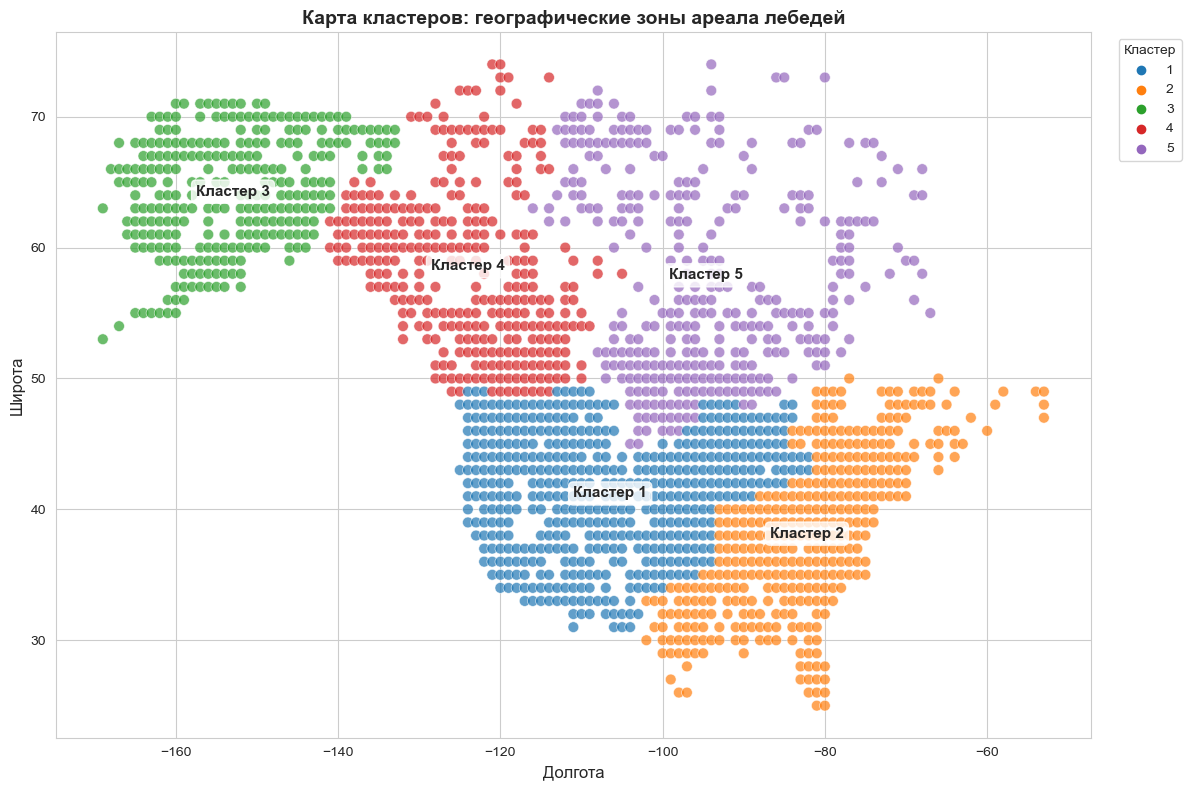

In [34]:
# Ваш код здесь

# Общий стиль
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


# ГРАФИК КАРТА КЛАСТЕРОВ 
fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=cells,
    x='decimal_longitude', y='decimal_latitude',
    hue='cluster', palette='tab10',
    s=60, alpha=0.7, edgecolor='white', linewidth=0.5,
    ax=ax
)

# Центроиды
centroids = cells.groupby('cluster')[['decimal_longitude', 'decimal_latitude']].mean()
for cl, row in centroids.iterrows():
    ax.annotate(f'Кластер {cl}',
                xy=(row['decimal_longitude'], row['decimal_latitude']),
                fontsize=11, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('Карта кластеров: географические зоны ареала лебедей', fontsize=14, fontweight='bold')
ax.set_xlabel('Долгота', fontsize=12)
ax.set_ylabel('Широта', fontsize=12)
ax.legend(title='Кластер', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



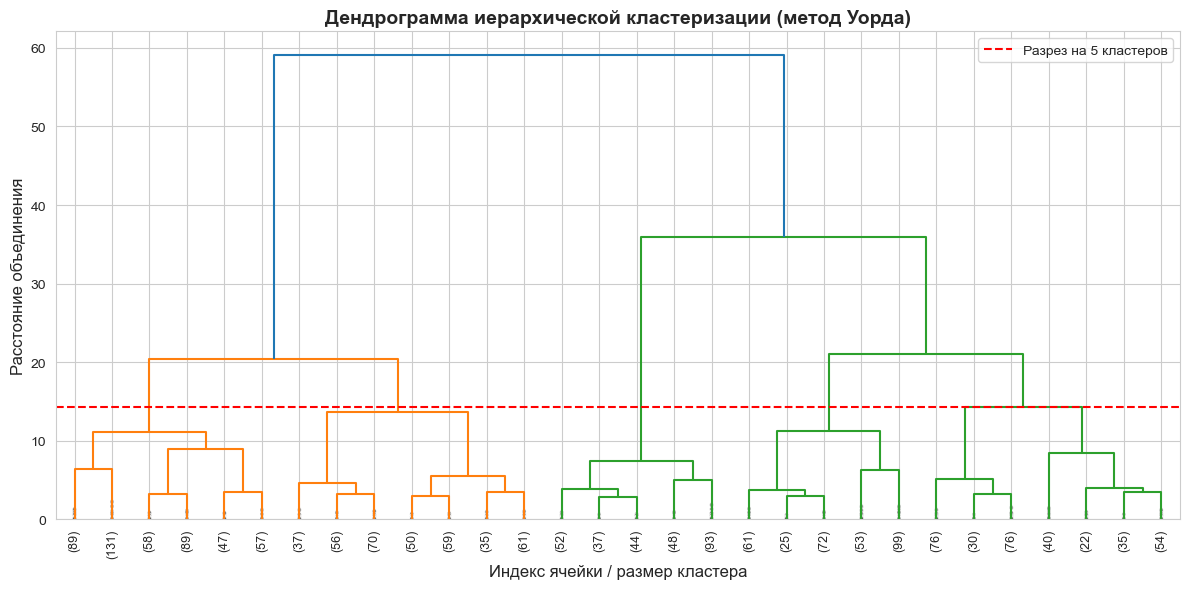

In [35]:
# ГРАФИК 2: ДЕНДРОГРАММА
fig, ax = plt.subplots(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',   # показываем только последние p слияний
    p=30,                    # число отображаемых «листьев»
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    ax=ax
)

ax.set_title('Дендрограмма иерархической кластеризации (метод Уорда)', fontsize=14, fontweight='bold')
ax.set_xlabel('Индекс ячейки / размер кластера', fontsize=12)
ax.set_ylabel('Расстояние объединения', fontsize=12)

# Горизонтальная линия разреза на 5 кластеров
ax.axhline(y=linkage_matrix[-5, 2], color='red', linestyle='--',
           linewidth=1.5, label='Разрез на 5 кластеров')
ax.legend()
plt.tight_layout()
plt.show()


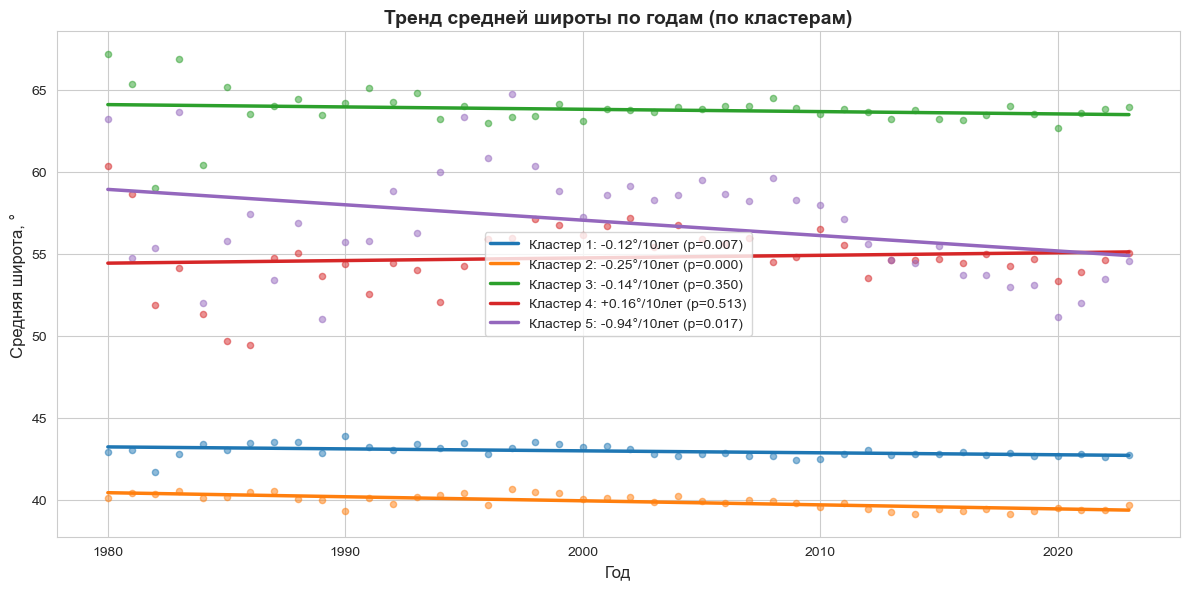

In [36]:
# ГРАФИК 3: ТРЕНД ШИРОТЫ ПО ГОДАМ (по кластерам) 
fig, ax = plt.subplots(figsize=(12, 6))

palette = sns.color_palette('tab10', 5)

for cl in sorted(data['cluster'].unique()):
    sub = data[data['cluster'] == cl]
    yearly = sub.groupby('year')['decimal_latitude'].mean()

    # Точки
    ax.scatter(yearly.index, yearly.values, s=20, alpha=0.5, color=palette[cl - 1])

    # Линия регрессии
    from scipy.stats import linregress
    slope, intercept, r, p, _ = linregress(yearly.index, yearly.values)
    x_line = np.array([yearly.index.min(), yearly.index.max()])
    y_line = intercept + slope * x_line
    ax.plot(x_line, y_line, linewidth=2.5, color=palette[cl - 1],
            label=f'Кластер {cl}: {slope*10:+.2f}°/10лет (p={p:.3f})')

ax.set_title('Тренд средней широты по годам (по кластерам)', fontsize=14, fontweight='bold')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Средняя широта, °', fontsize=12)
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

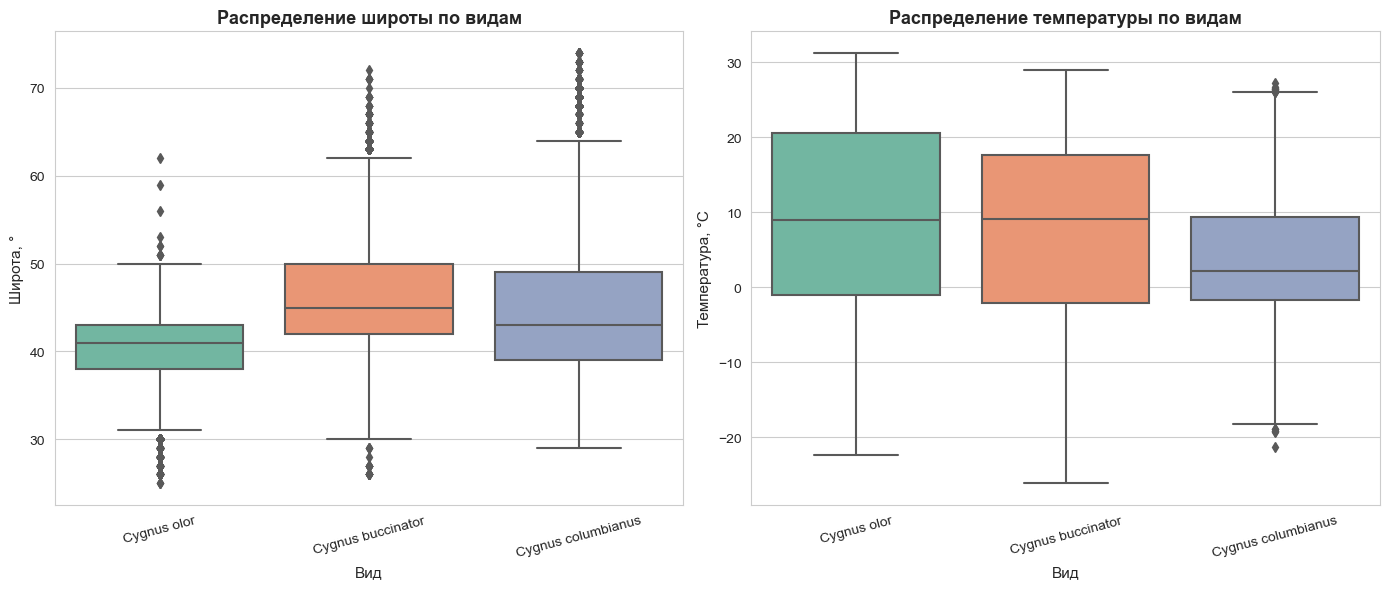

In [37]:
# ГРАФИК 4: BOXPLOT ПО ВИДАМ 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Широта по видам
sns.boxplot(
    data=data,
    x='species', y='decimal_latitude',
    palette='Set2', ax=axes[0]
)
axes[0].set_title('Распределение широты по видам', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Вид', fontsize=11)
axes[0].set_ylabel('Широта, °', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)

# Температура по видам
sns.boxplot(
    data=data,
    x='species', y='avg_temp_c',
    palette='Set2', ax=axes[1]
)
axes[1].set_title('Распределение температуры по видам', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Вид', fontsize=11)
axes[1].set_ylabel('Температура, °C', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 22. Выводы

> TODO: сформулируйте выводы в текстовом блоке:
> - наблюдается ли смещение ареала?
> - различается ли оно по кластерам?
> - какие различия между видами и сезонами?
> - какие ограничения анализа?

# Выводы

**Наблюдается ли смещение ареала?**

Формально — да: с каждым годом средняя широта наблюдений падает примерно на 0.04° (за 43 года — около 1.6°, то есть ~180 км к югу). Однако это скорее артефакт наблюдений, чем реальный сдвиг ареала. С 2010-х годов люди стали массово фиксировать птиц через мобильные приложения, и основной поток данных пошёл из густонаселённых южных штатов США. Лебеди, вероятно, никуда не переехали — просто их стали чаще замечать на юге. 
Здесь же стоит оговорить качество регрессионной модели: R² = 0.113 — то есть модель объясняет лишь около 11% дисперсии широты. Это ожидаемо, так как основной вклад в распределение вносят вид и сезон, а не сами по себе год, температура и плотность. 

**Различается ли смещение по кластерам?**

Да, очень сильно. Самый сильный и надёжный тренд — на *юго-востоке США* (−0.25°/10 лет, p ≈ 0, R² = 0.55). В *Скалистых горах* он слабее, но тоже значим (−0.12°/10 лет, p = 0.007). В *центре Канады* сигнал есть, но данных мало и разброс большой (−0.94°/10 лет, p = 0.017 при n = 1313). А вот на *Аляске* и *западе Канады* никакого смещения не видно — там ареал стабилен (p > 0.3). Такая картина косвенно подтверждает, что дело в наблюдателях: юг США густонаселён, туда идёт основной поток новых данных.

**Какие различия между видами и сезонами?**

Сезоны различаются однозначно. Лебеди мигрируют: зимой они в среднем на 7.5° южнее, чем летом — это ~830 км. По температуре разница ещё заметнее: зимой около 0°C, летом +17°C. Различия статистически значимы (Mann-Whitney, p ≈ 0).
Виды занимают разные широтные ниши, и все попарные различия значимы (p < 10⁻¹¹⁹):
- Лебедь-трубач (*C. buccinator*) — самый северный, медиана 45°.
- Тундровый лебедь (*C. columbianus*) — посередине, 43°, и самая низкая медианная температура (арктическое гнездование).
- Лебедь-шипун (*C. olor*) — самый южный, 41°; это согласуется с его интродукцией в густонаселённые районы США.

**Какие ограничения анализа?**

Во-первых, сильный временной перекос: 76% данных приходится на период после 2015 года. Ранние периоды (1980–1990-е) представлены слабо, и любые «тренды» могут отражать не поведение птиц, а изменение практики наблюдений.
Во-вторых, парадокс Симпсона**. Корреляции «в целом» обманчивы: связь широта–температура сильная внутри сезона (r до −0.88), но исчезает, если смешать зиму и лето (r ≈ 0). То же самое касается знака температуры в множественной регрессии.
В-третьих, сильное прореживание данных — с 1.3 млн до 33 тыс. записей (−97.4%). Это сделано осознанно: округление координат до 1° и удаление дублей по (год, сезон, широта, долгота, вид) позволяет анализировать ареал, а не плотность наблюдений. Но мелкомасштабная структура при этом теряется.
В-четвёртых, температуры усреднены по штату/провинции, а не по точке наблюдения. Для крупных регионов (Калифорния, Техас, Онтарио) это грубое приближение.
В-пятых, только 3 из 6 видов лебедей попали в анализ (по заданию). Инвазивные и редкие виды (чёрный лебедь, кликун, черношейный) не рассматривались.
И наконец, все выявленные связи — наблюдательные. Ни один результат не доказывает причинного влияния температуры или плотности населения на распределение птиц.

**Итог**

Статистически значимое смещение ареала лебедей в Северной Америке фиксируется, но направлено на юг и, вероятнее всего, отражает не поведение птиц, а изменение того, как и где люди за ними наблюдают. Смещение неоднородно по регионам: сильнее всего — на юго-востоке США, отсутствует на Аляске и западе Канады. Виды и сезоны чётко различаются по широте и температуре, и эти различия устойчивы ко всем проверкам. Для надёжных выводов о реальном смещении ареала необходима нормализация на наблюдательное усилие — это направление дальнейшей работы.